initializing ocelot...


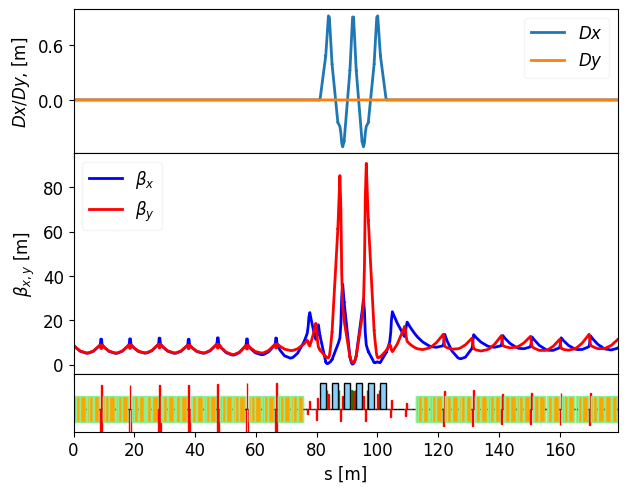

In [1]:
from ocelot import *
from ocelot.cpbd.elements import *
from ocelot.gui.accelerator import *
from ocelot.cpbd.track import track_debug
import matplotlib.pyplot as plt
import numpy as np


#from rfglinacbte import *
#from Jarc import *
from JarcCSR import *

#lat = MagneticLattice(lattice_list)
lat = MagneticLattice(lattice_list[0:1100])   



##### PA1RFGUN #####
# AX =-21.12   
# BX =24.36 
# AY =-21.16     
# BY =24.42      
# EMITX =1.2023504614117648e-06
# EMITY =1.2023504614117648e-06 
##### PA1RFGUN #####


##### PSECTB #####
AX =.8330530584703799  
BX =8.804855185360497    
AY =.8104567519439174
BY =8.82335409438248       
EMITX =10.2023504614117648e-06 
EMITY =10.2023504614117648e-06 
##### PSECTB #####

energy = 0.5 # GeV  #why?
tw0 = Twiss()
tw0.alpha_x = AX
tw0.beta_x = BX

tw0.alpha_y = AY
tw0.beta_y = BY
tw0.E = energy
tw0.emit_xn = EMITX 
tw0.emit_yn = EMITY
tw0.emit_x = EMITX   / energy * 0.511e-3
tw0.emit_y = EMITY / energy * 0.511e-3

tws = twiss(lat,tw0)

plot_opt_func(lat, tws,legend=False, grid=False, top_plot=['Dx','Dy'])

In [2]:
def gauss_from_twiss_vec(emit, beta, alpha, size=1):
    phi = 2 * np.pi * np.random.rand(size)
    u = np.random.rand(size)
    a = np.sqrt(-2 * np.log(1 - u) * emit)
    x = a * np.sqrt(beta) * np.cos(phi)
    xp = -a / np.sqrt(beta) * (np.sin(phi) + alpha * np.cos(phi))
    return x, xp

In [3]:
start_index = next(i for i, el in enumerate(lattice_list) if el.id == "PJARCM1")
end_index = next(i for i, el in enumerate(lattice_list) if el.id == "PSECTC")

sub_lat = MagneticLattice(lattice_list[start_index:end_index + 1])

R = lattice_transfer_map(sub_lat, energy=1.5)
print("R56 = ", R[4,5]*1000, "mm")


R56 =  -0.27711775672648775 mm


In [ ]:

# # Load the saved files
# loaded_rparticles = np.load("particles_rparticles.npy")  # Make sure this file exists
# loaded_q_array = np.load("particles_q_array.npy")        # And this too

# # Create particle array with the correct number of particles
# nparticles = loaded_rparticles.shape[1]
# p_array = ParticleArray(n=nparticles)

# import pickle

# with open("p_array_t.pkl", "rb") as f:
#     p_array = pickle.load(f)


# # Set beam energy (you need to define `energy` earlier in your code)
# p_array.E = energy

# # Assign the loaded values
# p_array.rparticles = loaded_rparticles
# p_array.q_array = loaded_q_array

import pickle

# Load the full ParticleArray (including rparticles, q_array, energy, etc.)
with open("p_array_t.pkl", "rb") as f:
    p_array = pickle.load(f)

#  confirm:
print("Number of particles loaded:", p_array.n)
print("Beam energy [GeV]:", p_array.E)


Number of particles loaded: 100000
Beam energy [GeV]: 0.4719693203529501


s = 0.100 m, σ_τ = 9.339e-04 s
z = 0.1 / 179.08170280000002. Applied: HookProcesss = 0.200 m, σ_τ = 9.339e-04 s
z = 0.2 / 179.08170280000002. Applied: HookProcesss = 0.300 m, σ_τ = 9.339e-04 s
z = 0.30000000000000004 / 179.08170280000002. Applied: HookProcesss = 0.400 m, σ_τ = 9.339e-04 s
z = 0.4 / 179.08170280000002. Applied: HookProcesss = 0.500 m, σ_τ = 9.339e-04 s
z = 0.5 / 179.08170280000002. Applied: HookProcesss = 0.600 m, σ_τ = 9.339e-04 s
z = 0.6 / 179.08170280000002. Applied: HookProcesss = 0.700 m, σ_τ = 9.339e-04 s
z = 0.7 / 179.08170280000002. Applied: HookProcesss = 0.800 m, σ_τ = 9.339e-04 s
z = 0.7999999999999999 / 179.08170280000002. Applied: HookProcesss = 0.900 m, σ_τ = 9.339e-04 s
z = 0.8999999999999999 / 179.08170280000002. Applied: HookProcesss = 1.000 m, σ_τ = 9.339e-04 s
z = 0.9999999999999999 / 179.08170280000002. Applied: HookProcesss = 1.100 m, σ_τ = 9.339e-04 s
z = 1.0999999999999999 / 179.08170280000002. Applied: HookProcesss = 1.200 m, σ_τ = 9.339e-04 s
z 

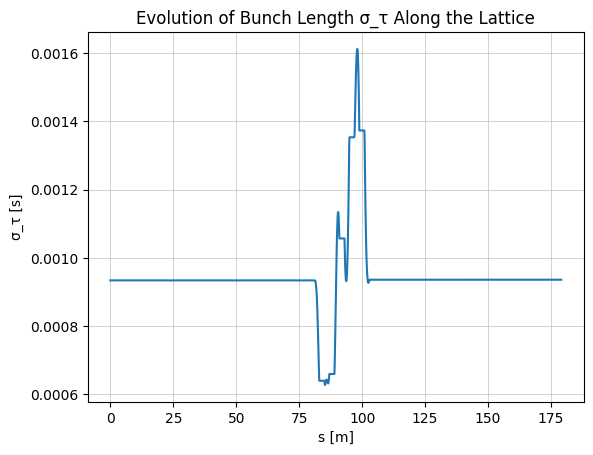

In [5]:
import time
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
from ocelot.cpbd.physics_proc import PhysProc

# Create the Navigator
navi = Navigator(lat)
navi.unit_step = 0.1  # high-resolution steps

# CSR example (optional)
csr = CSR(n_bin=500, m_bin=5, sigma_min=.2e-6)
navi.add_physics_proc(csr, csrm1_start, csrm1_end)

# Define the hook as a physics process
class HookProcess(PhysProc):
    def __init__(self, sigma_tau_list):
        super().__init__()
        self.sigma_tau_list = sigma_tau_list

    def apply(self, p_array, step_size):
        sigma_tau = np.std(p_array.rparticles[4])
        self.sigma_tau_list.append(sigma_tau)
        print(f"s = {self.z0:.3f} m, σ_τ = {sigma_tau:.3e} s")

# Attach the custom hook process
sigma_tau_list = []
hook_proc = HookProcess(sigma_tau_list)
navi.add_physics_proc(hook_proc, lat.sequence[0], lat.sequence[-1])

# Track
p_array_t = deepcopy(p_array)
start = time.time()
tws_track, p_array_t = track(lat, p_array_t, navi)
print("\n time exec:", time.time() - start, "sec")

# Plot
print("sigma_tau_list length:", len(sigma_tau_list))
print("lat.totalLen:", lat.totalLen)

s_axis = np.linspace(0, lat.totalLen, len(sigma_tau_list))
plt.plot(s_axis, sigma_tau_list)
plt.xlabel("s [m]")
plt.ylabel("σ_τ [s]")
plt.title("Evolution of Bunch Length σ_τ Along the Lattice")
plt.grid(True)
plt.show()



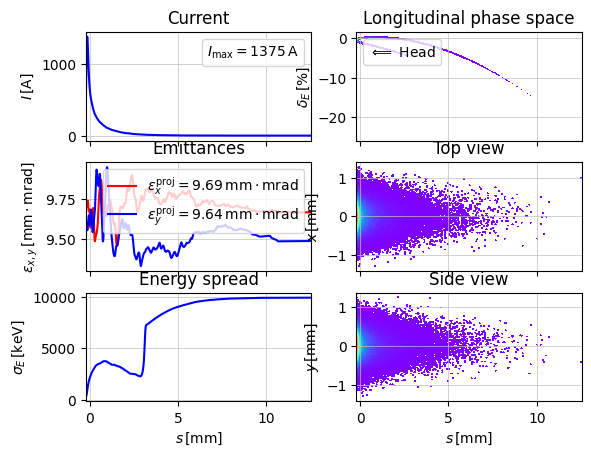

In [6]:
show_e_beam(p_array)

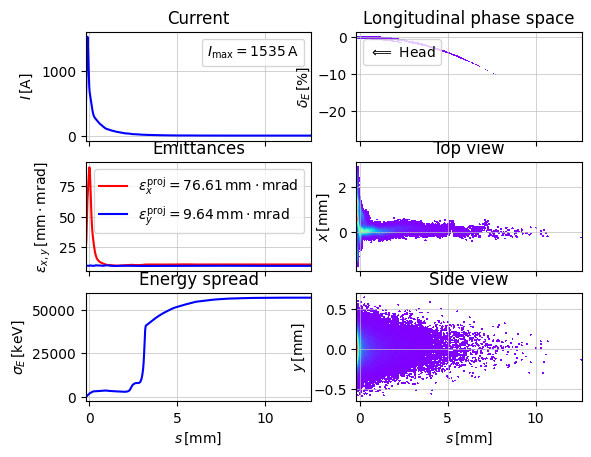

In [7]:
show_e_beam(p_array_t)

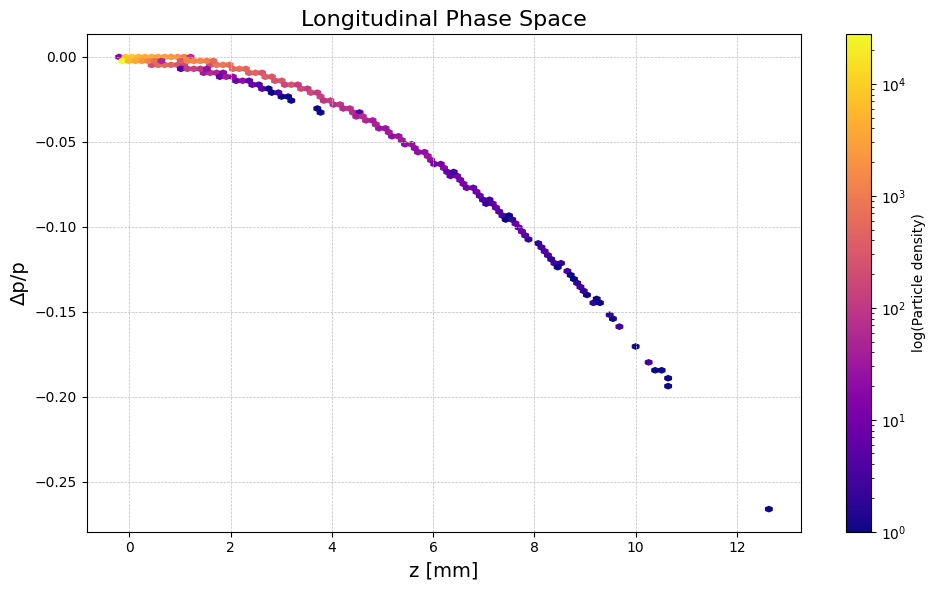

In [8]:
# Longitudinal phase space: z vs. Δp/p
z = p_array_t.rparticles[4]   # in meters
dp_p = p_array_t.rparticles[5]  # unitless

plt.figure(figsize=(10, 6))

hb = plt.hexbin(z * 1e3, dp_p, gridsize=100, cmap='plasma', bins='log')  # log scale improves contrast
plt.colorbar(hb, label='log(Particle density)')

plt.xlabel("z [mm]", fontsize=14)
plt.ylabel("Δp/p", fontsize=14)
plt.title("Longitudinal Phase Space", fontsize=16)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_energy_vs_position(tws_track):
    """
    Plot energy E as a function of position s from a list of Twiss-like objects.

    Parameters:
    tws_track (list): List of objects with attributes 's' (position) and 'E' (energy).
    """
    s = np.array([tw.s for tw in tws_track])
    E = np.array([tw.E for tw in tws_track])

    plt.figure(figsize=(10, 6))
    plt.plot(s, E, linewidth=2, marker='o', markersize=4)

    plt.title("Energy vs Position", fontsize=16)
    plt.xlabel("s (m)", fontsize=14)
    plt.ylabel("E (GeV)", fontsize=14)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tick_params(axis='both', labelsize=12)
    plt.tight_layout()
    plt.show()



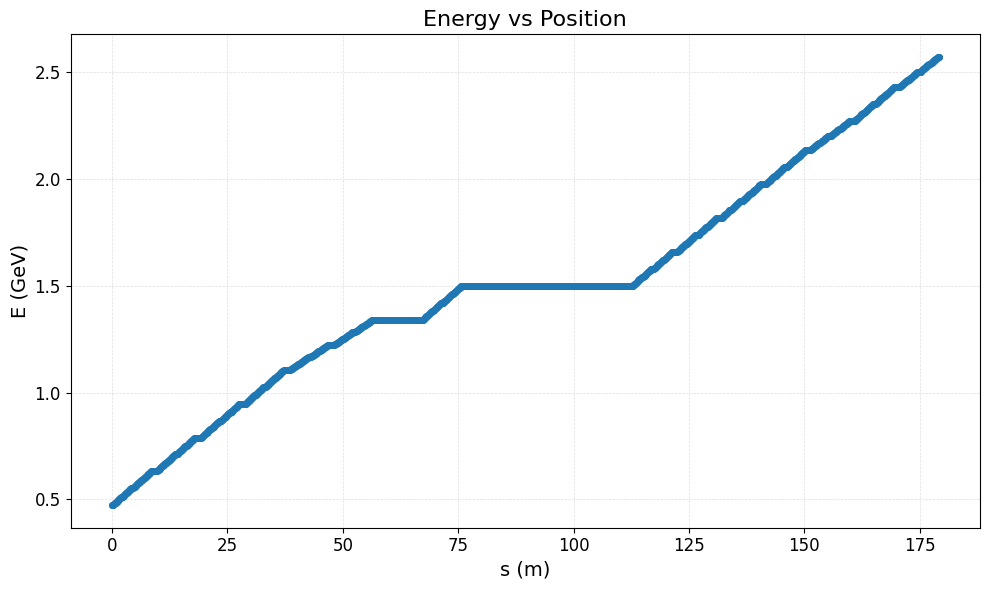

In [10]:
plot_energy_vs_position(tws_track)


In [11]:
np.sum(p_array.q_array)*1.e12

np.float64(1999.9999999999993)

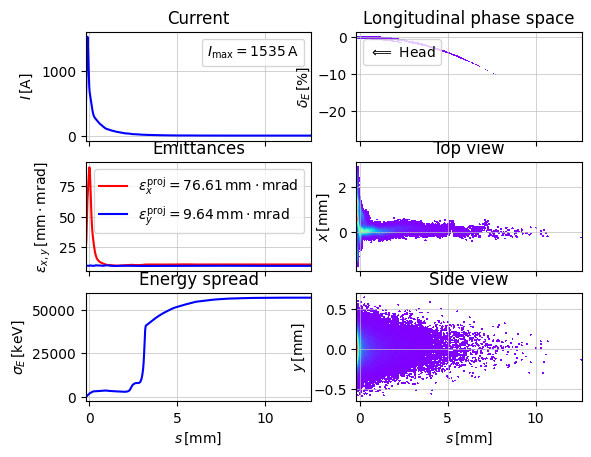

In [12]:
show_e_beam(p_array_t)

In [13]:
import pickle

with open("p_array_t_JARC.pkl", "wb") as f:
    pickle.dump(p_array_t, f)